In [310]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import gradio as gr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [311]:
movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python",
    header=None,
    names=["MovieID", "Title", "Genres"],
    encoding="latin-1"
)

ratings = pd.read_csv(
    "ratings.dat",
    sep="::",
    engine="python",
    header=None,
    names=["UserID", "MovieID", "Rating", "Timestamp"]
)

users = pd.read_csv(
    "users.dat",
    sep="::",
    engine="python",
    header=None,
    names=["UserID", "Gender", "Age", "Occupation", "ZipCode"]
)


The dataset has three files. Each file has loaded into Pandas to work with movies, users, and ratings.


In [312]:
movies.info()
ratings.info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   MovieID  3883 non-null   int64 
 1   Title    3883 non-null   object
 2   Genres   3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 
 1   Gender      6040 non-null   object
 

In [313]:
movies.head()


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [314]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [315]:
users.head()

,UserID,Gender,Age,Occupation,ZipCode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [316]:
movies.describe()

,MovieID
count,3883.000000
mean,1986.049446
std,1146.778349
min,1.000000
25%,982.500000
50%,2010.000000
75%,2980.500000
max,3952.000000


In [317]:
ratings.describe()

,UserID,MovieID,Rating,Timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


In [318]:
users.describe()

,UserID,Age,Occupation
count,6040.000000,6040.000000,6040.000000
mean,3020.500000,30.639238,8.146854
std,1743.742145,12.895962,6.329511
min,1.000000,1.000000,0.000000
25%,1510.750000,25.000000,3.000000
50%,3020.500000,25.000000,7.000000
75%,4530.250000,35.000000,14.000000
max,6040.000000,56.000000,20.000000


In [319]:
print("movies:",movies.shape)
print("ratings:",ratings.shape)
print("users:",users.shape)

movies: (3883, 3)
ratings: (1000209, 4)
users: (6040, 5)


The dataset has 3,883 movies, more than 1 million ratings, and 6,040 users.

In [320]:
movies.isnull().sum()

,0
MovieID,0
Title,0
Genres,0


In [321]:
ratings.isnull().sum()

,0
UserID,0
MovieID,0
Rating,0
Timestamp,0


In [322]:
users.isnull().sum()

,0
UserID,0
Gender,0
Age,0
Occupation,0
ZipCode,0


In [323]:
print("Duplicate movies:", movies.duplicated().sum())
print("Duplicate ratings:", ratings.duplicated().sum())
print("Duplicate users:", users.duplicated().sum())

Duplicate movies: 0
Duplicate ratings: 0
Duplicate users: 0


In [324]:
movies = movies.drop_duplicates()
ratings = ratings.drop_duplicates()
users = users.drop_duplicates()

In [325]:
len(ratings[ratings["Rating"].between(1, 5)])

movies["MovieID"].duplicated().sum()
users["UserID"].duplicated().sum()

ratings["MovieID"].isin(movies["MovieID"]).sum()
ratings["UserID"].isin(users["UserID"]).sum()

np.int64(1000209)

In [326]:
ratings = ratings[ratings["Rating"].between(1, 5)].copy()
ratings = ratings[
    ratings["MovieID"].isin(movies["MovieID"]) &
    ratings["UserID"].isin(users["UserID"])
].copy()

movies = movies.dropna(subset=["MovieID","Title"]).copy()
ratings = ratings.dropna(
    subset=["UserID","MovieID","Rating"]
).copy()
users = users.dropna(subset=["UserID"]).copy()

print("Cleaning completed")
print("Movies:",movies.shape)
print("Ratings:",ratings.shape)
print("Users:",users.shape)

Cleaning completed
Movies: (3883, 3)
Ratings: (1000209, 4)
Users: (6040, 5)


In [327]:
ratings["Rating"].value_counts().sort_index()

,count
Rating,
1,56174
2,107557
3,261197
4,348971
5,226310


In [328]:
genre_count = movies["Genres"].str.split("|").explode().value_counts()
print(genre_count.head(10))

Genres
Drama         1603
Comedy        1200
Action         503
Thriller       492
Romance        471
Horror         343
Adventure      283
Sci-Fi         276
Children's     251
Crime          211
Name: count, dtype: int64


Drama and Comedy are very common movie genres.

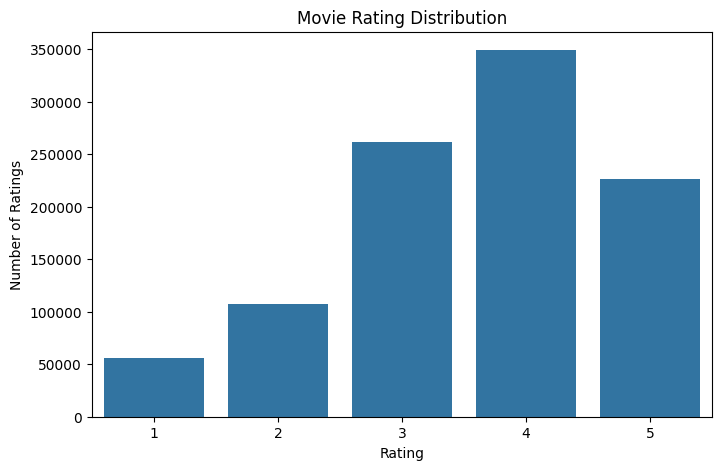

In [329]:
plt.figure(figsize=(8,5))
sns.countplot(data=ratings,x="Rating")
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

Rating 4 is the most common rating, followed by ratings 3 and 5.

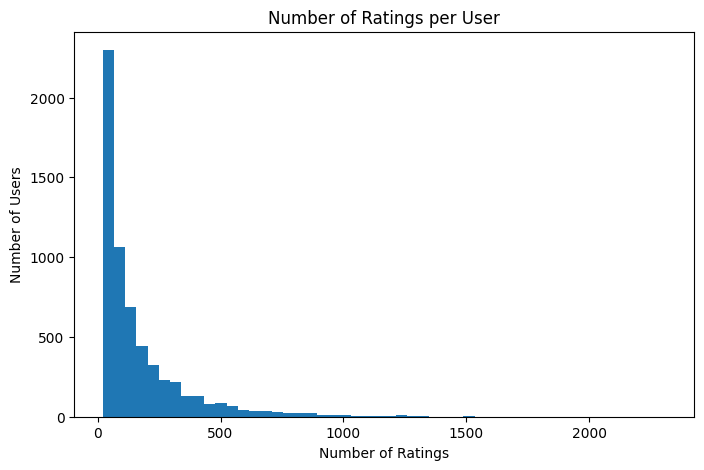

In [330]:
ratings_per_user = ratings.groupby("UserID").size()
plt.figure(figsize=(8,5))
plt.hist(ratings_per_user,bins=50)
plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

Most users rate only a few movies, while a small number rate 1,000+ movies. This creates an uneven pattern in the data.

In [331]:
movies["Genres"] = movies["Genres"].fillna("")

movies["Genres"]


,Genres
0,Animation|Children's|Comedy
1,Adventure|Children's|Fantasy
2,Comedy|Romance
3,Comedy|Drama
4,Comedy
...,...
3878,Comedy
3879,Drama
3880,Drama
3881,Drama


Genres used for identifying  simliar movies

In [332]:
movies["GenreText"] = movies["Genres"].str.replace("|", " ", regex=False)

movies["GenreText"]

,GenreText
0,Animation Children's Comedy
1,Adventure Children's Fantasy
2,Comedy Romance
3,Comedy Drama
4,Comedy
...,...
3878,Comedy
3879,Drama
3880,Drama
3881,Drama


GenreText helps to make Genre simple.

In [333]:
test_movies = [
    "Toy Story",
    "Jumanji",
    "Matrix",
    "Titanic",
    "Jurassic Park"
]

for movie in test_movies:
    print("\nMovie:", movie)
    print(recommend_movies(movie))


Movie: Toy Story
Aladdin and the King of Thieves (1996)
American Tail, An (1986)
American Tail: Fievel Goes West, An (1991)
Rugrats Movie, The (1998)
Bug's Life, A (1998)

Movie: Jumanji
Kids of the Round Table (1995)
Indian in the Cupboard, The (1995)
NeverEnding Story III, The (1994)
Escape to Witch Mountain (1975)
Labyrinth (1986)

Movie: Matrix
Nemesis 2: Nebula (1995)
Terminator 2: Judgment Day (1991)
Solo (1996)
Arrival, The (1996)
Lawnmower Man, The (1992)

Movie: Titanic
Leaving Las Vegas (1995)
Carrington (1995)
How to Make an American Quilt (1995)
When Night Is Falling (1995)
Postino, Il (The Postman) (1994)

Movie: Jurassic Park
Stargate (1994)
Star Trek: Generations (1994)
Jurassic Park (1993)
Star Trek: First Contact (1996)
Star Trek: The Motion Picture (1979)


In [334]:
movies = movies.reset_index(drop=True)
movies

,MovieID,Title,Genres,GenreText
0,1,Toy Story (1995),Animation|Children's|Comedy,Animation Children's Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy,Adventure Children's Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance
3,4,Waiting to Exhale (1995),Comedy|Drama,Comedy Drama
4,5,Father of the Bride Part II (1995),Comedy,Comedy
...,...,...,...,...
3878,3948,Meet the Parents (2000),Comedy,Comedy
3879,3949,Requiem for a Dream (2000),Drama,Drama
3880,3950,Tigerland (2000),Drama,Drama
3881,3951,Two Family House (2000),Drama,Drama


In [335]:
similarity= cosine_similarity(tfidf_matrix)
similarity

array([[1.        , 0.30552517, 0.19737232, ..., 0.        , 0.        ,
        0.        ],
       [0.30552517, 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.19737232, 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        0.52384694],
       [0.        , 0.        , 0.        , ..., 1.        , 1.        ,
        0.52384694],
       [0.        , 0.        , 0.        , ..., 0.52384694, 0.52384694,
        1.        ]])

In [336]:
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", len(train_ratings))
print("Testing ratings:", len(test_ratings))

Training ratings: 800167
Testing ratings: 200042


In [337]:
comparison = pd.DataFrame({
    "Method": ["TF-IDF", "CountVectorizer"],
    "Precision@5": [
        tfidf_metrics["Precision@5"],
        count_metrics["Precision@5"]
    ],
    "Recall@5": [
        tfidf_metrics["Recall@5"],
        count_metrics["Recall@5"]
    ]
})

print("Comparison of recommendation methods:")
print(comparison)

Comparison of recommendation methods:
            Method  Precision@5  Recall@5
0           TF-IDF     0.038000  0.005176
1  CountVectorizer     0.040667  0.005410


In [338]:
def evaluate_model(similarity_matrix, k=5):
    test_users = test_ratings["UserID"].unique()[:300]
    precision_scores = []
    recall_scores = []

    for user_id in test_users:
        user_train = train_ratings[
            (train_ratings["UserID"] == user_id) &
            (train_ratings["Rating"] >= 4)
        ]

        user_test = test_ratings[
            (test_ratings["UserID"] == user_id) &
            (test_ratings["Rating"] >= 4)
        ]

        if user_train.empty or user_test.empty:
            continue

        seed_movie_id = user_train.sort_values(
            "Rating", ascending=False
        ).iloc[0]["MovieID"]

        seed_index = movies.index[
            movies["MovieID"] == seed_movie_id
        ]

        if len(seed_index) == 0:
            continue

        seed_index = seed_index[0]

        scores = list(
            enumerate(similarity_matrix[seed_index])
        )

        already_seen = set(
            train_ratings.loc[
                train_ratings["UserID"] == user_id,
                "MovieID"
            ]
        )

        scores = [
            (i, score)
            for i, score in scores
            if movies.iloc[i]["MovieID"] not in already_seen
        ]

        scores = sorted(
            scores,
            key=lambda x: x[1],
            reverse=True
        )

        recommended_ids = [
            movies.iloc[i]["MovieID"]
            for i, score in scores[:k]
        ]


        relevant_ids = set(user_test["MovieID"])
        hits = len(set(recommended_ids) & relevant_ids)
        precision_scores.append(hits / k)
        recall_scores.append(hits / len(relevant_ids))

    if len(precision_scores) == 0:
        return {"Precision@5": 0, "Recall@5": 0}

    return {
        "Precision@5": np.mean(precision_scores),
        "Recall@5": np.mean(recall_scores)
    }

In [339]:
tfidf_metrics = evaluate_model(similarity_tfidf)
count_metrics = evaluate_model(similarity_count)

evaluation_results = pd.DataFrame(
    [tfidf_metrics, count_metrics],
    index=["TF-IDF", "CountVectorizer"]
)

print(evaluation_results)

                 Precision@5  Recall@5
TF-IDF              0.038000  0.005176
CountVectorizer     0.040667  0.005410


Precision@5 shows how many of the 5 suggestions were relevant, while Recall@5 shows how many relevant movies were found. Both scores are used to compare the two methods fairly.

In [340]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies["GenreText"])
print(tfidf_matrix.shape)

(3883, 20)


In [341]:
def get_recommendations(movie_name, similarity_matrix, n=5):
    matches = movies[
        movies["Title"].str.lower().str.contains(
            movie_name.lower(),
            regex=False
        )
    ]

    if matches.empty:
        return []

    movie_index = matches.index[0]
    scores = list(enumerate(similarity_matrix[movie_index]))
    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = [
        (index, score)
        for index, score in scores
        if index != movie_index
    ]

    return [
        movies.iloc[index]["Title"]
        for index, score in scores[:n]
    ]

In [342]:
test_movie = "Toy Story"

tfidf_results = get_recommendations(
    test_movie,
    similarity_tfidf
)

count_results = get_recommendations(
    test_movie,
    similarity_count
)

comparison = pd.DataFrame({
    "TF-IDF": tfidf_results,
    "CountVectorizer": count_results
})

print(comparison)

                                       TF-IDF  \
0      Aladdin and the King of Thieves (1996)   
1                    American Tail, An (1986)   
2  American Tail: Fievel Goes West, An (1991)   
3                   Rugrats Movie, The (1998)   
4                        Bug's Life, A (1998)   

                              CountVectorizer  
0      Aladdin and the King of Thieves (1996)  
1                    American Tail, An (1986)  
2  American Tail: Fievel Goes West, An (1991)  
3                   Rugrats Movie, The (1998)  
4                        Bug's Life, A (1998)  


In [349]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies["GenreText"])
similarity_tfidf = cosine_similarity(tfidf_matrix)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (3883, 20)


tfidf gives more importance to useful genre information and allows to calculate movie similarity.

In [345]:
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(movies["GenreText"])
similarity_count = cosine_similarity(count_matrix)

print("Count Vectorizer shape:", count_matrix.shape)

Count Vectorizer shape: (3883, 20)


CountVectorizer simply counts the genre.

In [346]:
def recommend_tfidf(movie_name, n=5):

    matches = movies[
        movies["Title"].str.lower().str.contains(
            movie_name.lower(),
            regex=False
        )
    ]

    if len(matches) == 0:
        return []

    index = matches.index[0]
    scores = list(enumerate(similarity_tfidf[index]))
    scores = sorted(scores,key=lambda x: x[1], reverse=True)

    return [
        movies.iloc[i]["Title"]
        for i, score in scores[1:n+1]
    ]

In [347]:
joblib.dump(tfidf, "movie_tfidf.pkl")
joblib.dump(similarity_tfidf, "movie_similarity.pkl")
movies.to_pickle("movies.pkl")

print("Model and movie data saved successfully!")

Model and movie data saved successfully!


In [348]:
tfidf_loaded = joblib.load("movie_tfidf.pkl")
similarity_loaded = joblib.load("movie_similarity.pkl")
movies_loaded = pd.read_pickle("movies.pkl")

print("Saved model loaded successfully!")
print("Number of movies:", len(movies_loaded))

Saved model loaded successfully!
Number of movies: 3883
